# Opioid Misuse Prediction Models

*Yiyu Wang 2024/04/19*

In [ ]:
data_dir = '../data/'
figures_dir = '../figures_mv_imputed/'
model_dir = '../model_results_mv_imputed/'


In [ ]:

PREDICTOR_COLUMNS = ['Age', 'Hispanic', 'Income', 'Education', 'Disability',
'Pain_duration',  'Average_pain_intensity', 'Worst_pain_intensity','Current_pain_intensity',
'Opioid_years', 'PainInterference', 'Anger', 'Anxiety', 'Depression',
'Fatigue', 'GlobalPhysical', 'GlobalMental', 'PhysicalFunction',
'SleepDisturbance', 'PCS_total', 'PCS_helplessness',
'PCS_rumination', 'PCS_magnification',  'DAST_total',
'AEQ', 'CTQ_EmotionalAbuse','AUDIT_total', 
'CTQ_PhysicalAbuse', 'CTQ_EmotionalNeglect', 'CTQ_PhysicalNeglect',
'CTQ_SexualAbuse', 'CTQ_total', 'White', 'Female', 'Married',
'Employed']


print(PREDICTOR_COLUMNS)
print('n predictors =', len(PREDICTOR_COLUMNS))
test_size = 0.2
SEED = 42

['Age', 'Hispanic', 'Income', 'Education', 'Disability', 'Pain_duration', 'Average_pain_intensity', 'Worst_pain_intensity', 'Current_pain_intensity', 'Opioid_years', 'PainInterference', 'Anger', 'Anxiety', 'Depression', 'Fatigue', 'GlobalPhysical', 'GlobalMental', 'PhysicalFunction', 'SleepDisturbance', 'PCS_total', 'PCS_helplessness', 'PCS_rumination', 'PCS_magnification', 'DAST_total', 'AEQ', 'CTQ_EmotionalAbuse', 'AUDIT_total', 'CTQ_PhysicalAbuse', 'CTQ_EmotionalNeglect', 'CTQ_PhysicalNeglect', 'CTQ_SexualAbuse', 'CTQ_total', 'White', 'Female', 'Married', 'Employed']
n predictors = 36


In [ ]:

import glob
from sklearn.metrics import roc_auc_score, mean_squared_error, root_mean_squared_error
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings('ignore')


# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.metrics import r2_score

import prediction

In [ ]:
df = pd.read_csv(data_dir + 'M_K23_ML_reduced_mv_imputed.csv')
df.head()

In [ ]:
# split select participants with commtot > 9
which_group = 'all'    
if which_group == 'high':
    df = df.loc[df['commtot'] > 9].reset_index(drop=True)
    df.to_csv(data_dir + f'M_K23_ML_group-{which_group}_reduced_mv_imputed_collapsed.csv', index=False)
elif which_group == 'low':
    df = df.loc[df['commtot'] <= 9].reset_index(drop=True)
    df.to_csv(data_dir + f'M_K23_ML_group-{which_group}_reduced_mv_imputed_collapsed.csv', index=False)
elif which_group == 'all':
    pass
    df.to_csv(data_dir + f'M_K23_ML_group-{which_group}_reduced_mv_imputed_collapsed.csv', index=False)

df.describe().to_csv(data_dir + f'M_K23_ML_group-{which_group}_reduced_mv_imputed_describe_collapsed.csv')
df.describe()    

# fit models

In [ ]:
# create hyperparameter grid for each model

models_list = [RandomForestRegressor(), XGBRegressor(), SVR(), Lasso(), Ridge(), ElasticNet(), MLPRegressor()]
param_grid_list = [
    {
        'n_estimators': list(range(50, 500, 50)),
        'max_depth': [4, 8, 16],
        'min_samples_split': [2, 4, 8],
        'min_samples_leaf': [1, 2, 4]
    },
    {
        'n_estimators': list(range(50, 500, 50)),
        'max_depth': [4, 8, 16],
        'learning_rate': [0.01, 0.1, 0.3]
    },
    {
        'C': [0.1, 1, 10],
        'gamma': [0.01, 0.1, 1],
        'kernel': ['rbf', 'linear']
    },
    {
        'alpha': [0.1, 0.5, 1, 5, 10],
        'max_iter': [100, 200, 300, 400]
    },
    {
        'alpha': [0.1, 0.5, 1, 5, 10],
        'max_iter': [100, 200, 300, 400]
    },
    {
        'alpha': [0.1, 0.5, 1, 5, 10],
        'l1_ratio': [0.1, 0.5, 0.9],
        'max_iter': [100, 200, 300, 400]
    },
    {
        'hidden_layer_sizes': [(100,), (200,), (300,)],
        'activation': ['tanh', 'relu', 'logistic'],
        'solver': ['adam', 'sgd'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate': ['constant', 'adaptive', 'invscaling'],
        'learning_rate_init': [0.0001, 0.001, 0.005, 0.01, 0.05]
    }
]

X_train, X_test, y_train, y_test = prediction.split_data(df, split_data = 'split', outcome = 'commtot', predictor_columns=PREDICTOR_COLUMNS, test_size = test_size, SEED = SEED)

for i in enumerate(models_list):
    model = i[1]
    model_name = model.__class__.__name__
    print(model_name)
    param_grid = param_grid_list[i[0]]
    GS = GridSearchCV(model, param_grid, cv=5, scoring=['r2', 'neg_mean_squared_error'], refit = 'r2', n_jobs=-1, verbose =0)
    GS.fit(X_train, y_train)

    cv_df = pd.DataFrame(GS.cv_results_)
    cv_df.to_csv(model_dir + f'{model_name}_grid_search_results_group-{which_group}.csv', index=False)
    joblib.dump(GS, model_dir + f'{model_name}_GS_best_model.pkl')


    


In [ ]:
# running model based on the hyperparameters with the highest r2 score
model_results = {}
for model in models_list:
    model_name = model.__class__.__name__
    print(model_name)
    cv_df = pd.read_csv(model_dir + f'{model_name}_grid_search_results_group-{which_group}.csv')
    best_model_index = cv_df['rank_test_r2'].idxmin()
    best_model_param = eval(cv_df.loc[best_model_index, 'params'])
    best_model = model.set_params(**best_model_param)
    joblib.dump(best_model, model_dir + f'{model_name}_rank_best_model_group-{which_group}.pkl')
    model_results[model_name] = prediction.mc_cv_ml_pipeline(best_model, df, split='split', outcome='commtot', test_size=test_size, n_split=100, predictor_columns=PREDICTOR_COLUMNS)

joblib.dump(model_results, model_dir + f'rank_model_mc_results_group-{which_group}.pkl')



RandomForestRegressor
Mean RMSE: 4.247, 95% CI: [3.471, 5.041]
Mean R: 0.574, 95% CI: [0.342, 0.709]
Median R: 0.582
XGBRegressor
Mean RMSE: 4.352, 95% CI: [3.508, 5.181]
Mean R: 0.549, 95% CI: [0.328, 0.712]
Median R: 0.556
SVR
Mean RMSE: 4.263, 95% CI: [3.595, 4.932]
Mean R: 0.577, 95% CI: [0.349, 0.707]
Median R: 0.600
Lasso
Mean RMSE: 4.177, 95% CI: [3.418, 4.823]
Mean R: 0.594, 95% CI: [0.388, 0.710]
Median R: 0.602
Ridge
Mean RMSE: 4.285, 95% CI: [3.591, 4.890]
Mean R: 0.581, 95% CI: [0.368, 0.728]
Median R: 0.597
ElasticNet
Mean RMSE: 4.117, 95% CI: [3.411, 4.803]
Mean R: 0.610, 95% CI: [0.399, 0.725]
Median R: 0.621
MLPRegressor
Mean RMSE: 4.409, 95% CI: [3.570, 6.689]
Mean R: 0.554, 95% CI: [0.224, 0.690]
Median R: 0.583


['../model_results_mv_imputed/rank_model_mc_results_group-all.pkl']

# make bar plots:

0.6097074322488906


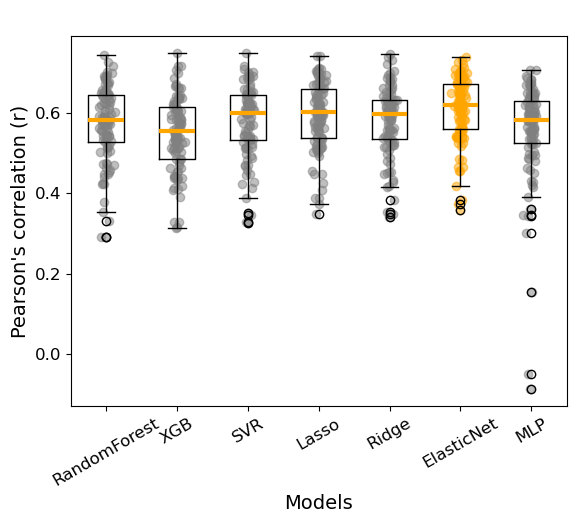

In [38]:
# r2 rank test
# Extract the r_scores for each model

model_results = joblib.load(model_dir + f'rank_model_mc_results_group-{which_group}.pkl')
r_scores = [result['r_scores'] for result in model_results.values()]

# model labels:
model_labels = [model for model in model_results.keys()]
model_labels = [model.replace('Regressor', '') for model in model_labels]
# Find the model with the highest mean r_score
max_mean_index = np.argmax([results['mean_r'] for results in model_results.values()])
# max_mean_index = max_mean_index + 2
# Create a box plot
plt.boxplot(r_scores, labels=model_labels, medianprops = dict(color = "orange", linewidth = 3))

# Add scatter points
for i, r_score in enumerate(r_scores):
    if i == max_mean_index:
        color = 'orange'  # Set the color of the model with the highest mean
        print(np.nanmean(r_score))
    else:
        color = 'gray'  # Set the color of other models to gray
    x = np.random.normal(i + 1, 0.04, size=len(r_score))
    plt.scatter(x, r_score, alpha=0.5, color=color)

# Customize font sizes
axis_fontsize = 14
xtick_fontsize = 12
ytick_fontsize = 12
title_fontsize = 16

plt.xlabel('Models', fontsize=axis_fontsize)
plt.ylabel("Pearson's correlation (r)", fontsize=axis_fontsize)
# plt.title('Distribution of correlation values by model', fontsize=title_fontsize)
plt.title(' ', fontsize=title_fontsize)

plt.xticks(fontsize=xtick_fontsize, rotation=30)
plt.yticks(fontsize=ytick_fontsize)


# save figure
plt.savefig(figures_dir + f'rank_models_box_plot_mean_r_score_group-{which_group}.png', dpi=300, bbox_inches='tight')
plt.show()


0.3851057808718751


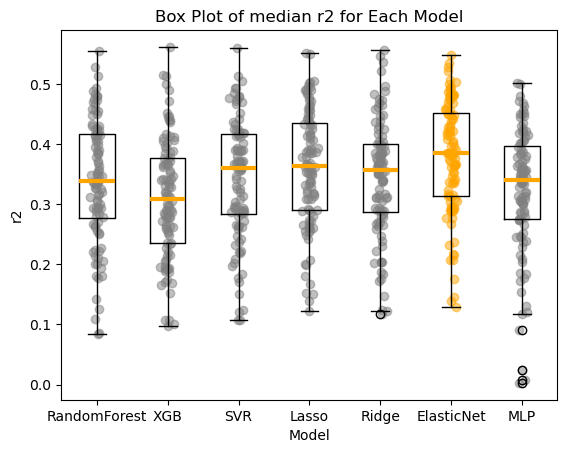

In [40]:
# plot r2

model_results = joblib.load(model_dir + f'rank_model_mc_results_group-{which_group}.pkl')
r_scores = [result['r_scores'] for result in model_results.values()]
r2_scores = [result['r2_scores'] for result in model_results.values()]
# model labels:
model_labels = [model for model in model_results.keys()]
model_labels = [model.replace('Regressor', '') for model in model_labels]
# Find the model with the highest mean r_score
max_mean_index = np.argmax([results['median_r'] for results in model_results.values()])

# Create a box plot
plt.boxplot(r2_scores, labels=model_labels, medianprops = dict(color = "orange", linewidth = 3))

# Add scatter points
for i, r2_score in enumerate(r2_scores):
    if i == max_mean_index:
        color = 'orange'  # Set the color of the model with the highest mean
        print(np.nanmedian(r2_score))
        
    else:
        color = 'gray'  # Set the color of other models to gray
    x = np.random.normal(i + 1, 0.04, size=len(r2_score))
    plt.scatter(x, r2_score, alpha=0.5, color=color)

plt.xlabel('Model')
plt.ylabel('r2')
plt.title('Box Plot of median r2 for Each Model')
#plt.xticks(rotation=45)

# save figure
plt.savefig(figures_dir + f'rank_models_box_plot_median_r2_group-{which_group}.png', dpi=300, bbox_inches='tight')
plt.show()

4.116893444379495


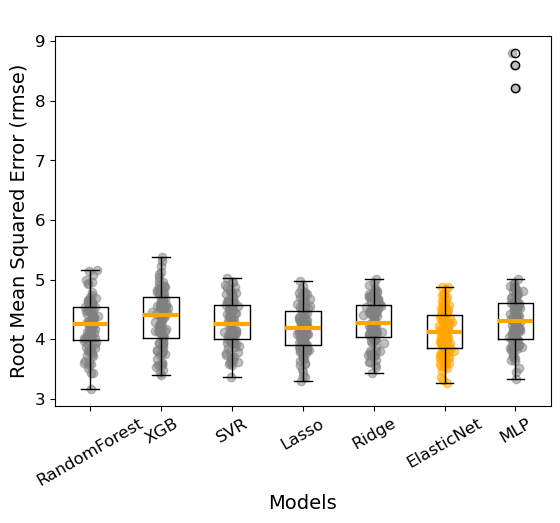

In [41]:
# compare RMSE for each model

model_results = joblib.load(model_dir + f'rank_model_mc_results_group-{which_group}.pkl')
r_scores = [result['rmse_scores'] for result in model_results.values()]

# model labels:
model_labels = [model for model in model_results.keys()]
model_labels = [model.replace('Regressor', '') for model in model_labels]
# Find the model with the highest mean r_score
max_mean_index = np.argmin([results['mean_rmse'] for results in model_results.values()])

# Create a box plot
plt.boxplot(r_scores, labels=model_labels, medianprops = dict(color = "orange", linewidth = 3))

# Add scatter points
for i, r_score in enumerate(r_scores):
    if i == max_mean_index:
        color = 'orange'  # Set the color of the model with the highest mean
        print(np.nanmean(r_score))
    else:
        color = 'gray'  # Set the color of other models to gray
    x = np.random.normal(i + 1, 0.04, size=len(r_score))
    plt.scatter(x, r_score, alpha=0.5, color=color)

# Customize font sizes
axis_fontsize = 14
xtick_fontsize = 12
ytick_fontsize = 12
title_fontsize = 16

plt.xlabel('Models', fontsize=axis_fontsize)
plt.ylabel("Root Mean Squared Error (rmse)", fontsize=axis_fontsize)
# plt.title('Distribution of correlation values by model', fontsize=title_fontsize)
plt.title(' ', fontsize=title_fontsize)

plt.xticks(fontsize=xtick_fontsize, rotation=30)
plt.yticks(fontsize=ytick_fontsize)


# save figure
plt.savefig(figures_dir + f'rank_models_box_plot_mean_rmse_group-{which_group}.png', dpi=300, bbox_inches='tight')
plt.show()


# make ablation plot

In [10]:
# select the best model from both the rank test

final_best_model_name = 'ElasticNet'
models_list = [RandomForestRegressor(), XGBRegressor(), SVR(), Lasso(), Ridge(), ElasticNet(), MLPRegressor()]
model = models_list[[model.__class__.__name__ for model in models_list].index(final_best_model_name)]

cv_df = pd.read_csv(model_dir + f'{final_best_model_name}_grid_search_results_group-{which_group}.csv')
best_model_index = cv_df['rank_test_r2'].idxmin()
best_model_param = eval(cv_df.loc[best_model_index, 'params'])

final_best_model = model.set_params(**best_model_param)

final_best_model

ElasticNet(alpha=5, max_iter=100)

In [46]:
final_best_model.get_params()

{'alpha': 5,
 'copy_X': True,
 'fit_intercept': True,
 'l1_ratio': 0.5,
 'max_iter': 100,
 'positive': False,
 'precompute': False,
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'warm_start': False}

In [ ]:
ablation = False
if ablation:
    ablation_results = {}
    df = pd.read_csv(data_dir + f'M_K23_ML_group-{which_group}_reduced_mv_imputed_collapsed.csv')
    # df = df.rename(columns=rename_dict)
    
    for c in PREDICTOR_COLUMNS:
        print(c)
        ablated_df = df.copy()
        ablated_df[c] = 0
        ablation_results[c] = prediction.mc_cv_ml_pipeline(final_best_model, ablated_df, split='split', n_split=100, outcome='commtot')
        
    # save ablation results
    joblib.dump(ablation_results, model_dir + f'{final_best_model_name}_ablation_results_group-{which_group}.pkl')    
else:
    ablation_results = joblib.load(model_dir + f'{final_best_model_name}_ablation_results_group-{which_group}.pkl')

Age
Mean RMSE: 4.111, 95% CI: [3.407, 4.803]
Mean R: 0.611, 95% CI: [0.400, 0.725]
Median R: 0.621
Hispanic
Mean RMSE: 4.117, 95% CI: [3.411, 4.803]
Mean R: 0.610, 95% CI: [0.399, 0.725]
Median R: 0.621
Income
Mean RMSE: 4.117, 95% CI: [3.411, 4.803]
Mean R: 0.610, 95% CI: [0.399, 0.725]
Median R: 0.621
Education
Mean RMSE: 4.117, 95% CI: [3.411, 4.803]
Mean R: 0.610, 95% CI: [0.399, 0.725]
Median R: 0.621
Disability
Mean RMSE: 4.117, 95% CI: [3.411, 4.803]
Mean R: 0.610, 95% CI: [0.399, 0.725]
Median R: 0.621
Pain_duration
Mean RMSE: 4.117, 95% CI: [3.411, 4.803]
Mean R: 0.610, 95% CI: [0.399, 0.725]
Median R: 0.621
Average_pain_intensity
Mean RMSE: 4.117, 95% CI: [3.411, 4.803]
Mean R: 0.610, 95% CI: [0.399, 0.725]
Median R: 0.621
Worst_pain_intensity
Mean RMSE: 4.117, 95% CI: [3.411, 4.803]
Mean R: 0.610, 95% CI: [0.399, 0.725]
Median R: 0.621
Current_pain_intensity
Mean RMSE: 4.117, 95% CI: [3.411, 4.803]
Mean R: 0.610, 95% CI: [0.399, 0.725]
Median R: 0.621
Opioid_years
Mean RMSE:

In [ ]:
orig_model_results = prediction.mc_cv_ml_pipeline(final_best_model, df, split='split', n_split=100, outcome='commtot')
orig_r = orig_model_results['mean_r']
orig_r_scores = orig_model_results['r_scores']
# Find the model with the highest mean r_score
sorted_ablation_index = np.argsort([np.mean(result['r_scores']) for result in ablation_results.values()])
labels = [list(ablation_results.keys())[i] for i in sorted_ablation_index]
ablated_r_scores = [result['r_scores'] for result in ablation_results.values()]
ablated_r_scores.sort(key=np.mean)

# gather delta_r, delta_r2, delta_r_ci
delta_r_list, delta_r2_list, delta_r_ci_list = [], [], []
delta_p = []
for i, r_score in enumerate(ablated_r_scores):
    column = PREDICTOR_COLUMNS[i]
    delta_r_dist = orig_model_results['r_scores'] - np.array(r_score)
    delta_r_list.append(delta_r_dist)
    delta_r2 = [r**2 for r in delta_r_dist]
    delta_r2_list.append(delta_r2)
    SE = np.std(delta_r_dist)/np.sqrt(len(delta_r_dist))
    mean = np.mean(delta_r_dist)
    delta_r_ci = (mean + 1.96 * SE) - (mean - 1.96 * SE)
    delta_r_ci_list.append(delta_r_ci)
    delta_p.append(np.percentile(delta_r_dist, 97.5) - np.percentile(delta_r_dist, 2.5))


x_sorted: ['Anxiety' 'Depression' 'CTQ_total' 'Age' 'Fatigue' 'PCS_total' 'AEQ'
 'Anger']
y_sorted: [-0.00236641 -0.00230995 -0.00208704 -0.00158193  0.00212322  0.00774995
  0.02208372  0.0529828 ]


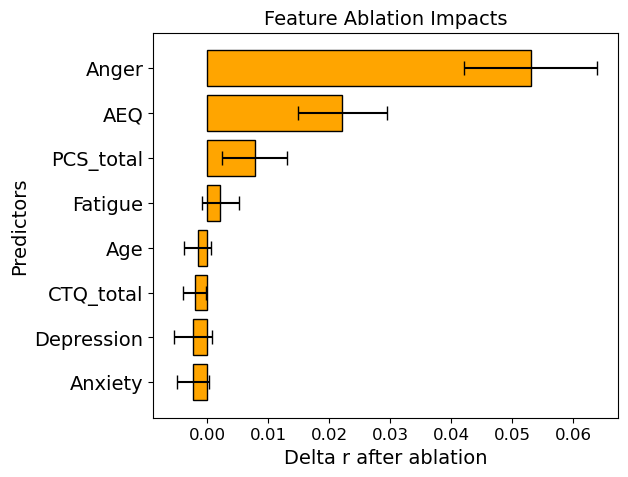

In [58]:
# Compute mean delta r for each feature
mean_delta_r = np.mean(delta_r_list, axis=1)

# Find indices where the mean delta r is non-zero (with a small tolerance to avoid float precision issues)
nonzero_delta_indices = np.where(np.abs(mean_delta_r) > 1e-3)[0]

# Filter everything accordingly
x_filtered = np.array(labels)[nonzero_delta_indices]
y_filtered = mean_delta_r[nonzero_delta_indices]
yerr_filtered = np.array(delta_r_ci_list)[nonzero_delta_indices]

# Sort for plotting
sorted_indices = np.argsort(y_filtered)
x_sorted = x_filtered[sorted_indices]
y_sorted = y_filtered[sorted_indices]
yerr_sorted = yerr_filtered[sorted_indices]
print(f"x_sorted: {x_sorted}")
print(f"y_sorted: {y_sorted}")


# Plot
plt.figure(figsize=(6, 5))
plt.barh(x_sorted, y_sorted, xerr=np.abs(yerr_sorted), capsize=5, color='orange', edgecolor='black')
plt.ylabel('Predictors', fontsize=14)
plt.xlabel('Delta r after ablation', fontsize=14)
plt.title('Feature Ablation Impacts', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.savefig(figures_dir + f'{final_best_model_name}_ablation_analysis_group-{which_group}_nonzero_deltar.png', dpi=300, bbox_inches='tight')
plt.show()


ElasticNet


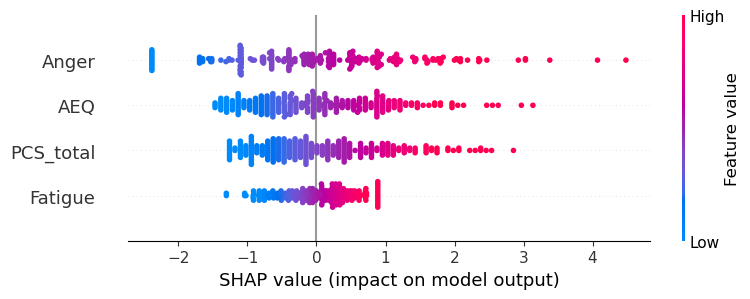

In [ ]:
import shap
which_group = 'all'
print(final_best_model_name)
df = pd.read_csv(data_dir + f'M_K23_ML_group-{which_group}_reduced_mv_imputed_collapsed.csv')
X_train, X_test, y_train, y_test = prediction.split_data(df, split_data = 'split', outcome = 'commtot', predictor_columns=PREDICTOR_COLUMNS, test_size = test_size, SEED=SEED)
model = joblib.load(model_dir + f'{final_best_model_name}_rank_best_model_group-{which_group}.pkl')
model.fit(X_train, y_train)
# Create a SHAP explainer
explainer = shap.Explainer(model, X_train)
shap_values = explainer.shap_values(X_train)


# find the index for Anger, Fatigue, AmbivalenceExpression, PCS_total, Anxiety, Depression
# plot the shap values for the selected features
col_interest = ['Anger', 'AEQ', 'PCS_total','Fatigue' ]
plot_idx = [X_train.columns.get_loc(col) for col in col_interest]
shap.summary_plot(shap_values[:, plot_idx], X_train.iloc[:, plot_idx], show=False, max_display=11)
# shap.summary_plot(shap_values, X_train, show=False, max_display=11)

# save the shap figure
plt.savefig(figures_dir + f'{final_best_model_name}_shap_summary_plot_group-{which_group}.png', dpi=300, bbox_inches='tight')
plt.show()

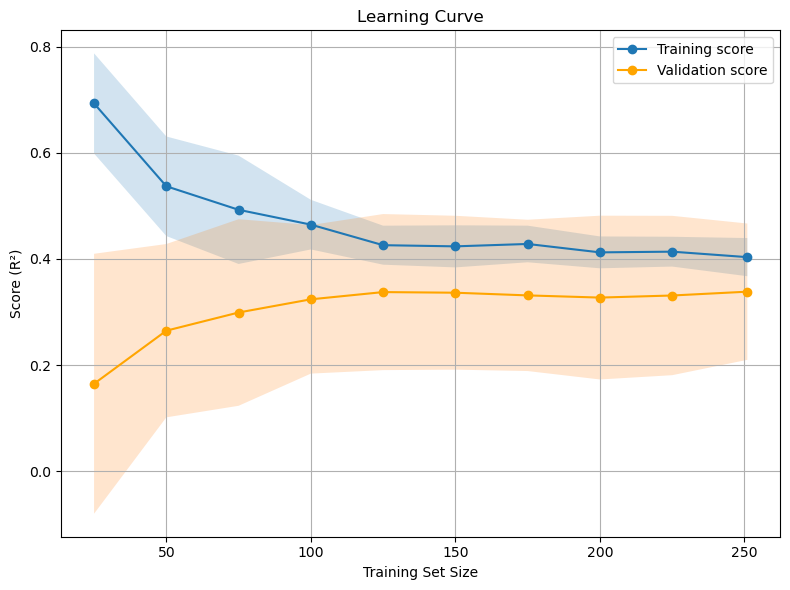

difference between training and validation scores:
0.06512252261062193


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit

X, y = df[PREDICTOR_COLUMNS], df['commtot']

# ---- Define model and CV ----
model = joblib.load(model_dir + f'{final_best_model_name}_rank_best_model_group-{which_group}.pkl')

cv = ShuffleSplit(n_splits=5, test_size=test_size, random_state=42)

# ---- Compute learning curve ----
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=cv, scoring='r2',  # Change scoring to fit your task
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# ---- Plot ----
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(train_sizes, val_mean, 'o-', label='Validation score', color='orange')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.xlabel("Training Set Size")
plt.ylabel("Score (R²)")
plt.title("Learning Curve")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

print("difference between training and validation scores:")
print(np.mean(train_scores[-1] - val_scores[-1]))
